# Credit Score Classification

**Name: Hans Richard Djojosantoso**

**NIM: 2802392492**

Dataset: data_C.csv 25.000 records nasabah

Target: `Credit_Score` (Standard / Good / Poor)

Link Penjelasan : https://drive.google.com/drive/folders/1cgNpi9DdaPkfwrArKOe-h9dwxwmHXjdi?usp=sharing

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from collections import Counter
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, 
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

## 2. Data Loading

In [2]:
df = pd.read_csv('../data_C.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.04750,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.00000,Standard,2500.04,27.57648,9 Years and 8 Months,Yes,26.16811,92.51897591535379,High_spent_Small_value_payments,303.91767,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.57167,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.00000,Standard,2149.9,23.45129,NaN,Yes,11.56444,54.46174813453877,Low_spent_Medium_value_payments,309.13098,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.07000,1,6,2,1,Auto Loan,25,4,5.04,1.00000,Good,387.53,31.10030,24 Years and 3 Months,No,98.03193,478.3574716999517,High_spent_Small_value_payments,920.81760,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,3,7,5,0,NaN,30,15,24.73,6.00000,Standard,987.07,26.78692,17 Years and 7 Months,Yes,0.00000,65.84983488267585,Low_spent_Large_value_payments,391.89033,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.73625,4,1405,14,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",30,19,16.44,7.00000,Standard,177.98,24.00175,14 Years and 7 Months,Yes,35.56273,NaN,Low_spent_Small_value_payments,228.24600,Standard


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

### 3.1. Column Drop

Kolom : ID, Customer_IS, Name, SSN. Tidak berpengaruh apapun ke dalam prediksi kita, karena kita mereka hanya digunakan sebagai identifier yang terlalu banyak mengandung nilai unik. 

In [4]:
df = df.drop(columns=['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN'])

### 3.2. Datatype Mismatch

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21164 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22148 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23208 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24528 non-null  float64
 14  Credit

There is some datatype mismatch in the cols:
- age (int)
- annual_income (float)
- num_of_loan (int)
- Num_of_Delayed_Payment(int)
- Changed_Credit_Limit(float)
- Outstanding_Debt (float)
- Amount_invested_monthly (float)

In [6]:
mis_col = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly']
mis_num_col = df[mis_col][~
                          df[mis_col]
                          .apply(lambda x : pd.to_numeric(x, errors='coerce'))
                          .notna()]

for i in mis_num_col:
    print(f"{i}: \n {mis_num_col[i].dropna().unique()}\n")

Age: 
 ['28_' '53_' '26_' '43_' '15_' '2756_' '19_' '29_' '32_' '18_' '25_' '34_'
 '50_' '41_' '6744_' '38_' '16_' '20_' '36_' '48_' '55_' '21_' '23_' '45_'
 '24_' '27_' '3307_' '30_' '31_' '39_' '49_' '22_' '51_' '40_' '44_' '54_'
 '17_' '2329_' '42_' '37_' '52_' '47_' '6799_' '33_' '1188_' '14_' '35_'
 '46_' '56_' '6381_' '3998_' '5769_' '2846_' '3988_' '780_' '2159_' '737_'
 '3712_' '3339_' '7316_' '1794_' '2171_' '8153_' '2155_' '5373_' '6666_'
 '4445_']

Annual_Income: 
 ['43534.9_' '28828.86_' '7780.49_' ... '43985.8_' '73509.02_' '21734.19_']

Num_of_Loan: 
 ['0_' '4_' '2_' '9_' '1_' '5_' '3_' '6_' '7_' '8_' '131_' '696_' '92_'
 '1459_']

Num_of_Delayed_Payment: 
 ['19_' '8_' '17_' '2_' '7_' '15_' '4_' '12_' '16_' '21_' '22_' '11_' '18_'
 '14_' '9_' '28_' '20_' '25_' '3_' '0_' '13_' '1_' '10_' '23_' '24_'
 '1323_' '6_' '5_' '1473_' '-2_' '183_' '27_' '-1_' '848_' '2237_']

Changed_Credit_Limit: 
 ['_']

Outstanding_Debt: 
 ['1449.78_' '1571.26_' '810.8_' '3818.57_' '783.52_' '44

semua kolom diatas seharusnya merupakan numerical column yang ada error karena ada tambahan '_' di valuenya, solusinya adalah replace aja dengan ''

In [7]:
df[mis_col] = df[mis_col].astype(str).replace('_', '', regex=False)
df[mis_col] = df[mis_col].apply(pd.to_numeric, errors='coerce')

### 3.3. Mapping the Target Variable

In [8]:
df['Credit_Score'].unique()

array(['Standard', 'Poor', 'Good'], dtype=object)

kolom target harus di map secara ordinal karena mengandung urutan

Good > Standard > Poor

2    > 1        > 0



In [9]:
df['Credit_Score'] = df['Credit_Score'].map({
    'Good' : 2,
    'Standard' : 1,
    'Poor' : 0
})

### 3.4. Duplicated 

In [10]:
df.duplicated().sum()

0

Tidak terdapat duplicated value

### 3.5. Missing Value

In [11]:
nan_info = pd.DataFrame({
    'Column': df.columns,
    'Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Percentage', ascending=False).reset_index(drop=True)

print(nan_info[nan_info['Count'] > 0])


                     Column  Count  Percentage
0     Monthly_Inhand_Salary   3836    15.34000
1              Type_of_Loan   2852    11.41000
2    Num_of_Delayed_Payment   2495     9.98000
3        Credit_History_Age   2240     8.96000
4   Amount_invested_monthly   2183     8.73000
5             Annual_Income   1778     7.11000
6                       Age   1245     4.98000
7               Num_of_Loan   1204     4.82000
8      Changed_Credit_Limit    518     2.07000
9      Num_Credit_Inquiries    472     1.89000
10          Monthly_Balance    301     1.20000
11         Outstanding_Debt    270     1.08000


monthly_inhand_salary menunjukkan missing value terbanyak, yang dimana saya akan imputasi nantinya didalam pipeline dengan median value dan yang kategorikal dengan modusnya

### 3.6. Categorical Column

In [12]:
cat_col = df.select_dtypes(include='object')
num_col = df.select_dtypes(exclude='object')

In [13]:
cat_col.columns

Index(['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Credit_History_Age', 'Payment_of_Min_Amount', 'Payment_Behaviour'],
      dtype='object')

In [14]:
for i in cat_col.columns:
    print(cat_col[i].value_counts())
    print("\n"*1)

Month
February    3203
March       3192
January     3146
June        3144
May         3115
August      3075
April       3068
July        3057
Name: count, dtype: int64


Occupation
_______          1765
Lawyer           1642
Mechanic         1621
Teacher          1618
Developer        1580
Journalist       1568
Scientist        1558
Accountant       1553
Media_Manager    1552
Architect        1550
Engineer         1549
Entrepreneur     1511
Doctor           1504
Manager          1497
Musician         1491
Writer           1441
Name: count, dtype: int64


Type_of_Loan
Not Specified                                                                                                                                             345
Debt Consolidation Loan                                                                                                                                   338
Student Loan                                                                                                  

#### 3.6.1. Payment Behaviour Error Vals + Feats Eng.

In [15]:
error_dist = df[df['Payment_Behaviour'] == '!@9#%8']['Credit_Score'].value_counts(normalize=True)
total_dist = df['Credit_Score'].value_counts(normalize=True)
comparison_df = pd.concat([total_dist, error_dist], axis=1)
comparison_df.columns = ['Total_Dataset_Proportion', 'Error_Data_Proportion']
print(comparison_df)

              Total_Dataset_Proportion  Error_Data_Proportion
Credit_Score                                                 
1                              0.53128                0.53819
0                              0.29072                0.27883
2                              0.17800                0.18298


In [16]:
df[df['Payment_Behaviour'] == '!@9#%8'].shape[0]/df.shape[0]

0.07804

In [17]:
df = df[df['Payment_Behaviour'] != '!@9#%8']

saya mempertimbangkan untuk 
- 1. Hapus datanya
- 2. mengubah value error jadi unknown untuk preserve data

namun solusi saya adalah untuk hapus saja data errornya karena error data itu mengikuti distribusi dari total dataset yang mengindikasikan kalo errornya ini missing at random dan data payment errornya hanya 7 persen dari dataset yang berarti sangat aman jika dihapus (tidak merubah distribusi asli), maka saya putuskan untuk hapus valuenya

In [18]:
pattern = r'(High|Low)_spent_(Small|Medium|Large)_value_payments'

df[['Spent_Level', 'Payment_Value']] = df['Payment_Behaviour'].str.extract(pattern)

df.drop(columns=['Payment_Behaviour'], inplace=True)

Feature Engineering Rationale :

Kolom payment behavior berisi gabungan dari tingkat pengeluaran dan ukuran transaksi, model bisa belajar lebih banyak dengan memisahkan fitur tersebut supaya model lebih tergeneralisasi. Dengan pemisahan fitur ini memungkinkan saya untuk menerapkan ordinal encoding secara efisien daripada OHE di fitur awal, lalu setelah dipisahkan fitur payment behavior dihapus agar tidak redundan (duplikat)

#### 3.6.2. Type of loan Explode data

Type of loan memiliki multiple value oleh karena itu jadi banyak banget unique valuenya tapi mereka merupakan value yang berulang, jadi saya akan pecah multiple valuenya lalu dihitung ada berapa frequencynya. Alasan saya pilih pendekatan ini karena menangkap kombinasi utang dan berapa kali mengutang yang dimana berkorelasi langsung dengan credit risk (lebih banyak loan = lebih tinggi risk)

In [19]:
valid_loans = ['Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'Payday Loan',
 'Personal Loan',
 'Student Loan']

loan_column = 'Type_of_Loan'

def get_loan_counts(loan_string='Type_of_Loan'):
    if pd.isna(loan_string) or str(loan_string).strip() == '':
        return Counter()
    
    loans = [item.strip() for item in str(loan_string).replace(' and ', ',').split(',')]
    
    return Counter([l for l in loans if l in valid_loans])

freq_dicts = df[loan_column].apply(get_loan_counts).tolist()

encoded_loans_df = pd.DataFrame(freq_dicts, index=df.index).fillna(0).astype(int)

encoded_loans_df.columns = [f"{col.replace(' ', '_').lower()}_freq" for col in encoded_loans_df.columns]

for loan in valid_loans:
    col_name = f"{loan.replace(' ', '_').lower()}_freq"
    if col_name not in encoded_loans_df.columns:
        encoded_loans_df[col_name] = 0

df = pd.concat([df, encoded_loans_df], axis=1)
df.drop(columns=[loan_column], inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23049 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         23049 non-null  object 
 1   Age                           21906 non-null  float64
 2   Occupation                    23049 non-null  object 
 3   Annual_Income                 21420 non-null  float64
 4   Monthly_Inhand_Salary         19509 non-null  float64
 5   Num_Bank_Accounts             23049 non-null  int64  
 6   Num_Credit_Card               23049 non-null  int64  
 7   Interest_Rate                 23049 non-null  int64  
 8   Num_of_Loan                   21929 non-null  float64
 9   Delay_from_due_date           23049 non-null  int64  
 10  Num_of_Delayed_Payment        20776 non-null  float64
 11  Changed_Credit_Limit          22578 non-null  float64
 12  Num_Credit_Inquiries          22614 non-null  float64
 13  Credit

#### 3.6.3. Occupation

In [21]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')

Occupation punya value invalid yaitu : _______ dalam jumlah signifikan (1.765 baris), membuat nya menjadi kelompok dengan frekuensi tertinggi di dataset. data ini tidak akan saya hapus karena akan membuang informasi berharga dari kolom lain, sedangkan kalo diimputasi pake modus bisa ngerusak distribusi data asli. Oleh karena itu saya buat dia jadi kategori sendiri bernama 'unknown' yang mencerminkan kondisi bahwa informasi terkait nasabahnya emg ga tau.

#### 3.6.4. Credit Mix

In [22]:
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)

Fitur Credit_Mix merupakan data kategorikal ordinal yang memiliki tingkatan nilai (Bad < Standard < Good). Dibandingkan imputasi modus yang melihat kelompok dengan frekuensi terbanyak, pendekatan ordinal imputation berbasis nilai median lebih baik karena mencari titik keseimbangan di tengah seluruh distribusi data. Metode ini lebih kebal (robust) terhadap risiko bias ekstrem, yang membuat pendekatan ini berhasil meminimalkan jarak kesalahan prediksi sekaligus menjaga struktur profil risiko nasabah agar tetap representatif bagi model machine learning.

#### 3.6.5. Payment of min amount

Payment_of_Min_Amount punya value NM yang saya asumsikan sebagai No Minimum atau nasabah bayar lunas, membuat fitur ini punya urutan tingkatan risiko yang jelas dari yang paling aman sampai yang paling bahaya. Oleh karena itu, saya buat dia pake Ordinal Encoding dengan urutan NM (0) sebagai risiko terendah karena bayar penuh, Yes (1) sebagai risiko sedang karena cuma cicil batas minim, dan No (2) sebagai risiko tertinggi karena nasabahnya emang nunggak tagihan.

#### 3.6.6. Credit history age convert

In [23]:
def month_converter(x):
    if pd.isna(x):
        return np.nan
    parts = x.split()
    tes = (pd.to_numeric(parts[0], errors='coerce') * 12 + pd.to_numeric(parts[3], errors='coerce'))
    return tes

df['Credit_History_Age'] = df['Credit_History_Age'].apply(month_converter).astype('float64')
df['Credit_History_Age'].head(10)

0    116.00000
1          NaN
2    291.00000
3    211.00000
4    175.00000
6    251.00000
7    281.00000
8          NaN
9    338.00000
10   268.00000
Name: Credit_History_Age, dtype: float64

#### 3.6.7. Update Cat Cols

In [24]:
cat_col = df.select_dtypes(include='object')

### 3.7. Numerical Column

In [25]:
num_col = df.select_dtypes(exclude='object').drop(columns=['Credit_Score'])

In [26]:
num_col.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,personal_loan_freq,student_loan_freq,mortgage_loan_freq,auto_loan_freq,payday_loan_freq,credit-builder_loan_freq,home_equity_loan_freq,debt_consolidation_loan_freq
count,21906.00000,21420.00000,19509.00000,23049.00000,23049.00000,23049.00000,21929.00000,23049.00000,20776.00000,22578.00000,22614.00000,22797.00000,23049.00000,20984.00000,23049.00000,21043.00000,22769.00000,23049.00000,23049.00000,23049.00000,23049.00000,23049.00000,23049.00000,23049.00000,23049.00000
mean,105.60595,164863.70419,4184.52030,18.13133,21.90230,75.34900,3.02499,21.02226,30.30323,10.40530,28.26519,1430.22011,32.26330,220.96631,1466.76370,194.56890,403.48651,0.39095,0.39229,0.38418,0.37780,0.40670,0.40028,0.38770,0.38904
std,660.58327,1362254.91980,3200.66566,122.54529,125.08684,479.70505,63.88753,14.87746,223.10518,6.82119,196.40575,1157.54845,5.12818,99.11015,8513.03290,198.94419,215.60698,0.64452,0.65124,0.63437,0.63331,0.66170,0.66234,0.64402,0.64392
min,-500.00000,7005.93000,303.64542,-1.00000,0.00000,1.00000,-100.00000,-5.00000,-3.00000,-6.44000,0.00000,0.34000,20.10077,2.00000,0.00000,0.00000,0.08863,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,24.00000,19199.93250,1609.90250,3.00000,4.00000,8.00000,1.00000,10.00000,9.00000,5.31000,3.00000,569.80000,28.03014,145.00000,30.30666,71.67602,269.91184,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
50%,33.00000,37424.16000,3073.92250,6.00000,5.00000,14.00000,3.00000,18.00000,14.00000,9.47000,6.00000,1166.08000,32.26563,219.00000,68.36676,127.88077,335.54563,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
75%,42.00000,72745.73000,5936.78000,7.00000,7.00000,20.00000,5.00000,28.00000,18.00000,14.93000,9.00000,1960.28000,36.48485,300.00000,159.99010,236.25504,473.20504,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
max,8678.00000,24160009.00000,15204.63333,1784.00000,1498.00000,5797.00000,1495.00000,67.00000,4384.00000,35.82000,2592.00000,4997.10000,50.00000,404.00000,82331.00000,1977.32610,1533.10227,4.00000,5.00000,5.00000,4.00000,5.00000,4.00000,5.00000,5.00000


Berikut adalah hasil terjemahan dalam bahasa Indonesia yang rapi dan menggunakan istilah data science yang umum untuk kebutuhan dokumentasi proyek Anda:

Interpretasi:

- Age: Normal.
- Annual_Income: Data memiliki anomali ekstrem karena nilai standar deviasi lebih besar daripada rata-rata (mean) dan nilai maksimumnya sangat tidak realistis dibandingkan dengan data lainnya.
- Monthly_Inhand_Salary: Terdapat data yang hilang (missing values), ditunjukkan oleh jumlah baris (count) yang lebih rendah dibandingkan fitur lainnya.
- Num_Bank_Accounts: Memiliki standar deviasi yang jauh di atas rata-rata; selain itu, nilai minimumnya adalah -1 (tidak masuk akal) dan nilai maksimumnya terlampau tinggi.
- Num_Credit_Card: Memiliki nilai ekstrem (outliers), karena sangat tidak mungkin seorang nasabah mempunyai 1.500 kartu kredit.
- Interest_Rate: Suku bunga juga tidak masuk akal karena tidak boleh melebihi 100 persen.
- Num_of_Loan: Memiliki nilai negatif dan nilai ekstrem (outliers).
- Delay_from_due_date: Terdapat nilai negatif.
- Num_of_Delayed_Payment: Memiliki nilai negatif dan nilai ekstrem (outliers).
- Changed_Credit_Limit: Memiliki nilai negatif namun tetap dapat diterima karena masuk akal secara logika bisnis (penurunan limit kredit).
- Num_Credit_Inquiries: Memiliki nilai ekstrem (outliers).
- Outstanding_Debt: Normal dan dapat diterima.
- Credit_Utilization_Ratio: Normal dan masuk akal.
- Total_EMI_per_month: Memiliki nilai ekstrem (outliers).
-  Amount_invested_monthly: Memiliki nilai ekstrem (outliers) dan standar deviasi yang jauh lebih besar daripada rata-rata.
- Monthly_Balance: Terdapat nilai negatif.

#### 3.7.1. Checking Negative Value and boxplot visualization

In [27]:
for col in num_col:
    if col == 'Changed_Credit_Limit':
       continue

    negative_mask = df[col] < 0
    negative_count = negative_mask.sum()
    negative_pct = (negative_count / len(df)) * 100
    min_val = df[col].min()
    
    if negative_count > 0:
        print(f"{col}:")
        print(f" Count: {negative_count} ({negative_pct:.2f}%)")
        print(f" Sample: {df[df[col] < 0][col].head(5).values}\n")

Age:
 Count: 213 (0.92%)
 Sample: [-500. -500. -500. -500. -500.]

Num_Bank_Accounts:
 Count: 4 (0.02%)
 Sample: [-1 -1 -1 -1]

Num_of_Loan:
 Count: 903 (3.92%)
 Sample: [-100. -100. -100. -100. -100.]

Delay_from_due_date:
 Count: 121 (0.52%)
 Sample: [-1 -2 -1 -4 -2]

Num_of_Delayed_Payment:
 Count: 132 (0.57%)
 Sample: [-2. -2. -2. -2. -2.]



alasan saya tidak mengalikan negatif valuenya adalah, value tersebut tidak masuk akal jika berada di value positif, seperti usia yang jadi 500, num of loan juga tidak masuk akal karena tidak mungkin ada orang yang ngambil 100 loan dan fitur lain juga begitu, maka akan sayaanggap data ini adalah data error dan karena hanya mempengaruhi sedikit dari total data maka akan saya anggap missing value yang tinggal di isi 

In [28]:
df.loc[negative_mask, col] = np.nan

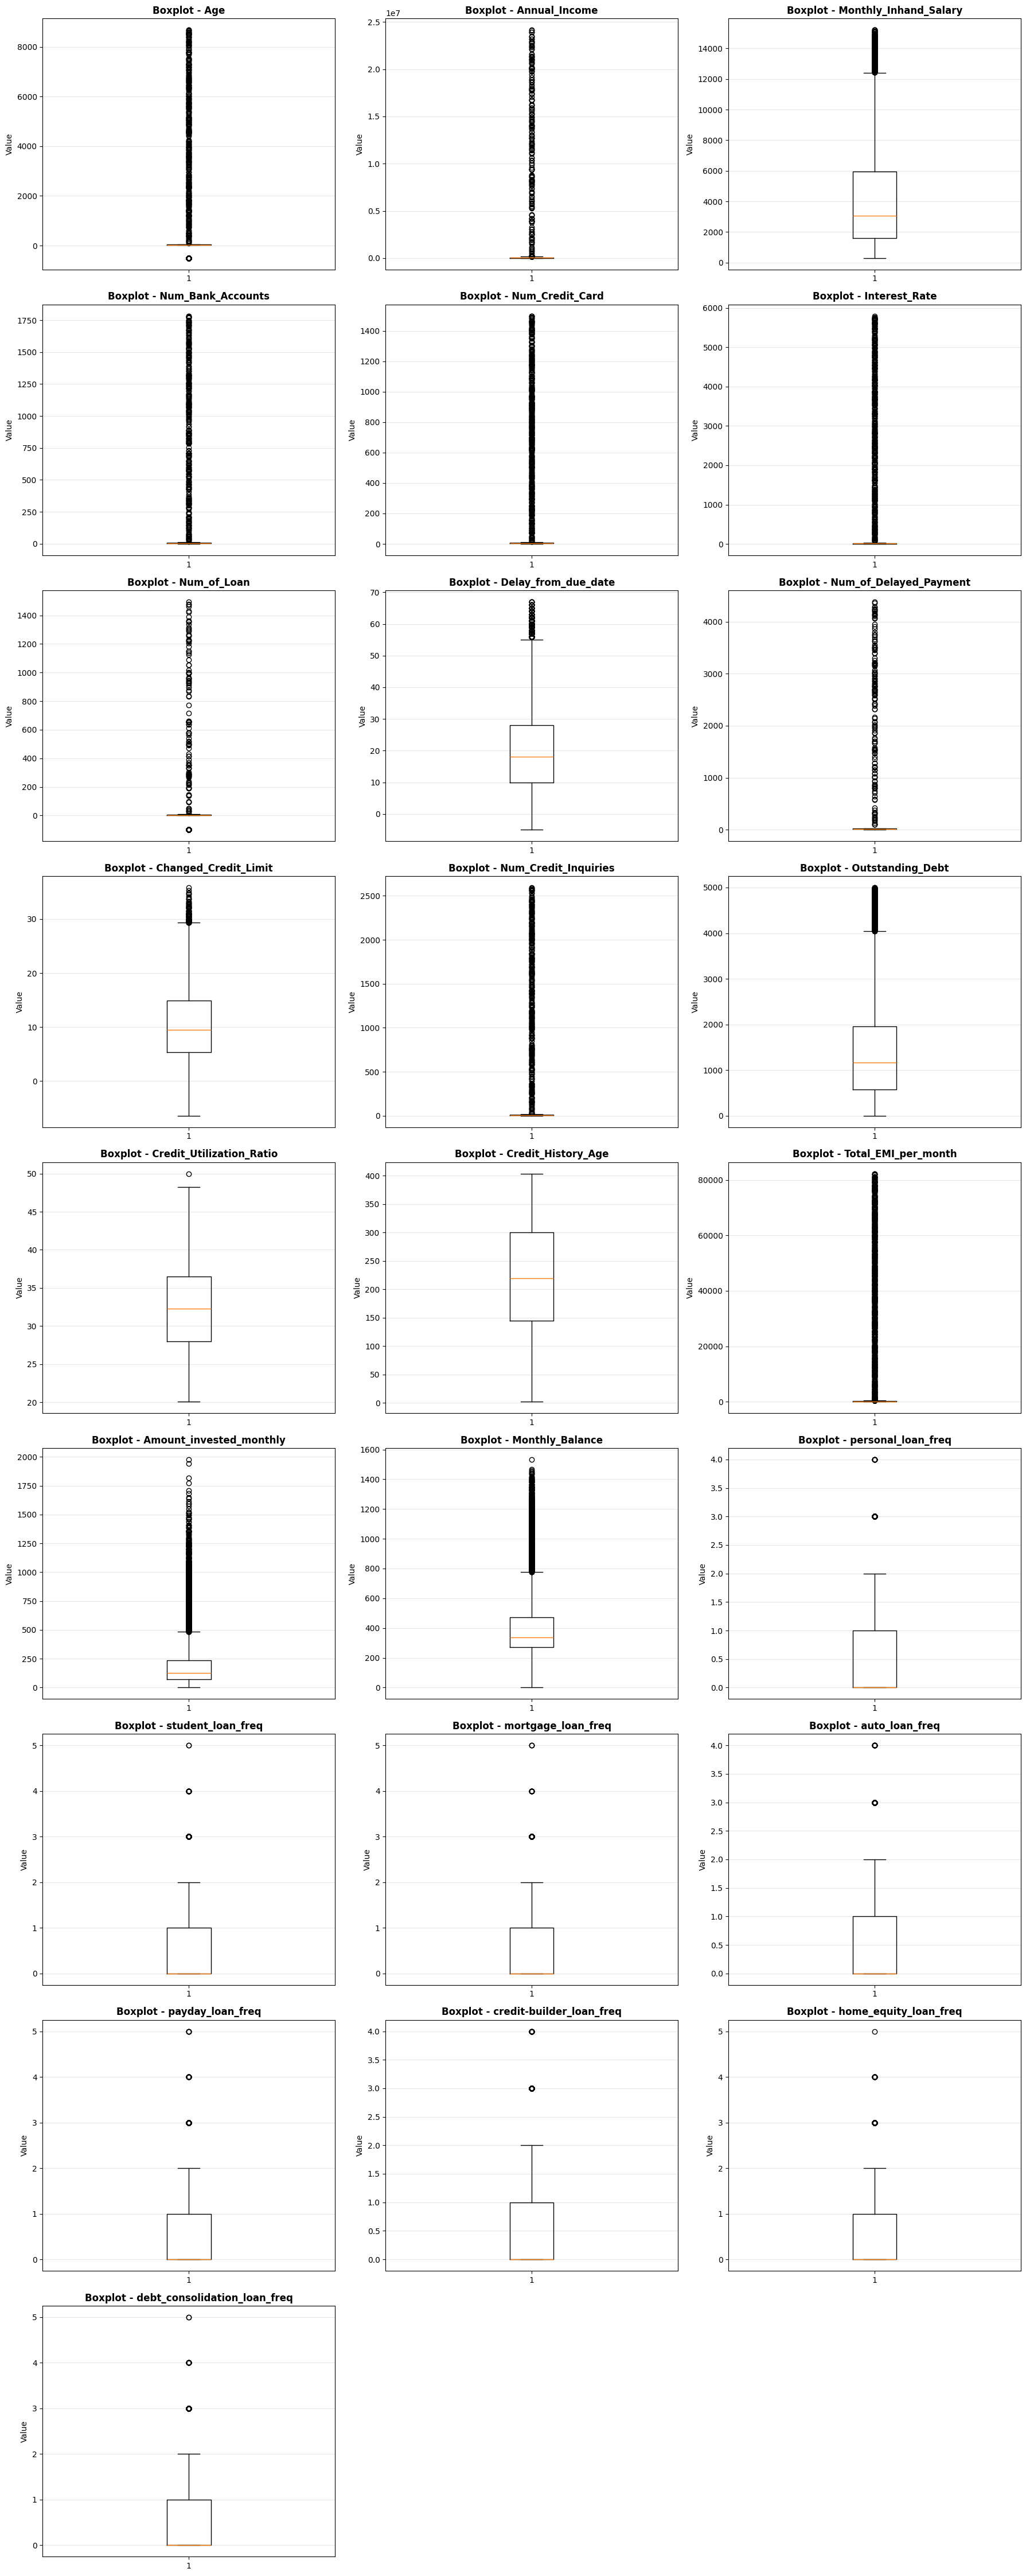

In [29]:
n_cols_per_row = 3
n_rows = (len(num_col.columns) + n_cols_per_row - 1) // n_cols_per_row

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_col):
    ax = axes[i]
    
    ax.boxplot(df[col].dropna())
    
    ax.set_title(f'Boxplot - {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 3.7.2. Age

In [30]:
reasonable_age = ((df['Age'] >= 18) & (df['Age'] <= 100)) | (df['Age'].isna())
df = df[reasonable_age]

saya berasumsi bahwa usia yang masuk akal untuk mendapatkan credit card adalah orang yang berusia diatas 17 dan dibawah 101, yang diatas 100 dan dibawah 18 tahun akan saya anggap sebagai outlier

#### 3.7.3. Annual Income

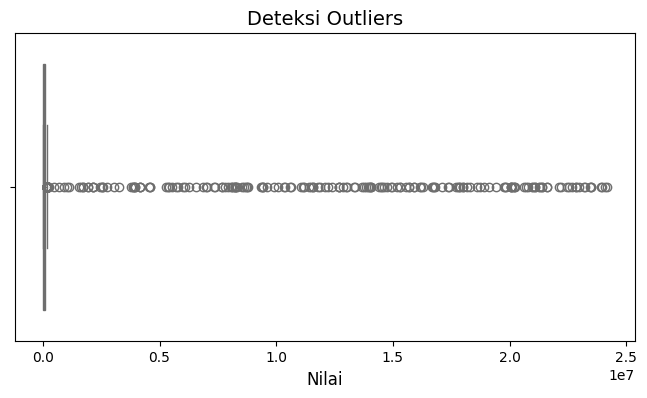

In [31]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Annual_Income'], color='lightcoral')

plt.title('Deteksi Outliers', fontsize=14)
plt.xlabel('Nilai', fontsize=12)

plt.show()

setelah di cek annual incomenya, terlihat bahwa banyak sekali outlier sampai melebihi batas nilai IQR, sehingga saya cek lebih lanjut dengan membatasi valuenya

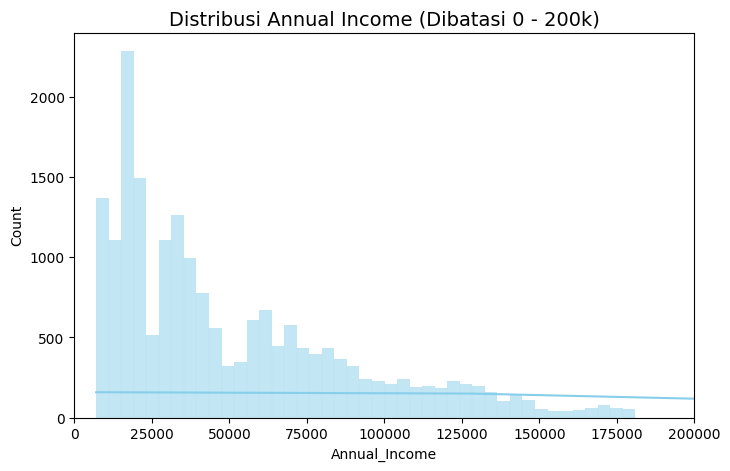

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Annual_Income'], kde=True, color='skyblue')

plt.xlim(0, 200000) 

plt.title('Distribusi Annual Income (Dibatasi 0 - 200k)', fontsize=14)
plt.show()

In [33]:
Q1 = df['Annual_Income'].quantile(0.25)
Q3 = df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 700000

df_not_null = df[df['Annual_Income'].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null['Annual_Income'] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null['Annual_Income'] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 237691.45
Jumlah data wajar: 19453 (99.07%)
Jumlah data anomali: 183 (0.93%)

Batas atas nominal sangat besar: 700000.00
Jumlah data wajar: 19456 (99.08%)
Jumlah data anomali: 180 (0.92%)


In [34]:
print(df[df['Annual_Income'] > upper_bound]['Annual_Income'].mean())

12510713.027322404


In [35]:
mask_anomali = df['Annual_Income'] > upper_bound

print("Distribusi Pekerjaan pada Data Anomali")
print(df[mask_anomali]['Occupation'].value_counts())

print("\nDistribusi Credit Mix pada Data Anomali")
print(df[mask_anomali]['Credit_Mix'].value_counts())

Distribusi Pekerjaan pada Data Anomali
Occupation
Accountant       16
Unknown          15
Musician         15
Media_Manager    14
Journalist       14
Entrepreneur     13
Doctor           12
Writer           11
Teacher          11
Engineer         11
Mechanic         10
Developer        10
Lawyer            9
Architect         9
Scientist         8
Manager           5
Name: count, dtype: int64

Distribusi Credit Mix pada Data Anomali
Credit_Mix
Good        61
Standard    55
Bad         35
Name: count, dtype: int64


In [36]:
df.loc[df['Annual_Income'] > upper_bound, 'Annual_Income'] = np.nan

Melalui perhitungan metode Interquartile Range (pengali 3), ditemukan batas atas wajar sebesar 237.691,45, di mana sekitar 0,93% data terdeteksi sebagai anomali dengan nilai mean tidak realistis mencapai 1,25 miliar. Setelah dilakukan analisis lintas fitur, kelompok anomali ini ternyata tersebar merata di seluruh jenis pekerjaan dan memiliki profil bauran kredit yang acak, sehingga disimpulkan bahwa data miliaran tersebut murni merupakan eror sistem acak dan bukan profil asli nasabah kelas atas. Oleh karena itu, solusi terbaik adalah dengan mengubah nilai anomali di atas batas wajar tersebut menjadi nan, lalu mengimputasinya menggunakan nilai median.

#### 3.7.4. Interest Rate

In [37]:
anomali_interest = (df['Interest_Rate'] < 0) | (df['Interest_Rate'] > 100)
print(f"Jumlah suku bunga tidak logis: {anomali_interest.sum()} baris")


Jumlah suku bunga tidak logis: 443 baris


In [38]:
df[anomali_interest].head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Spent_Level,Payment_Value,personal_loan_freq,student_loan_freq,mortgage_loan_freq,auto_loan_freq,payday_loan_freq,credit-builder_loan_freq,home_equity_loan_freq,debt_consolidation_loan_freq
1,August,46.00000,Teacher,9786.86000,951.57167,9,10,1663,2.00000,58,14.00000,15.53000,6.00000,Standard,2149.90000,23.45129,NaN,Yes,11.56444,54.46175,309.13098,0,Low,Medium,1,1,0,0,0,0,0,0.00000
16,May,42.00000,Journalist,83669.52000,6869.46000,8,6,405,3.00000,16,9.00000,12.22000,4.00000,Standard,1234.99000,25.92282,201.00000,Yes,179.52554,520.95307,266.46740,1,Low,Medium,1,0,0,1,0,0,1,0.00000
86,January,45.00000,Unknown,NaN,5352.38000,7,8,2369,4.00000,60,12.00000,NaN,7.00000,Standard,1599.30000,22.19672,NaN,Yes,146.19822,677.01907,2.02071,0,Low,Small,2,0,0,0,0,0,0,1.00000
308,March,36.00000,Lawyer,147221.48000,12046.45667,8,4,4170,4.00000,13,15.00000,24.07000,4.00000,Standard,722.28000,39.36593,306.00000,Yes,309.61136,357.99747,787.03683,1,High,Medium,0,1,0,0,1,0,1,1.00000
314,July,20.00000,Journalist,34500.97000,3046.08083,5,1,3684,4.00000,3,11.00000,4.40000,NaN,Good,1334.54000,25.61128,248.00000,No,71.80863,315.76287,207.03658,2,Low,Small,0,0,1,0,1,1,0,1.00000


In [39]:
df.loc[anomali_interest, 'Interest_Rate'] = np.nan

Berdasarkan aturan bisnis perbankan, nilai suku bunga kartu kredit secara logis harus berada di rentang 0 hingga 100 persen, sehingga angka di luar batasan tersebut dikategorikan sebagai data rusak atau anomali murni hasil kesalahan input sistem. Jadi akan saya hapus baris tersebut

In [40]:
col = 'Interest_Rate'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 39.50
Jumlah data wajar: 20693 (99.98%)
Jumlah data anomali: 4 (0.02%)


In [41]:
df[df[col] > upper_bound][col]

1372   87.00000
3215   75.00000
5115   73.00000
7611   74.00000
Name: Interest_Rate, dtype: float64

karena data anomali sangat sedikti dibandingkan degan data wajar maka akan saya anggap gapapa ada outlier yang nantinya bisa di kasih robust scaler aja karena juga datanya masih masuk akal kalo misal ada pinjaman yang high risk

#### 3.7.5. Number of loan

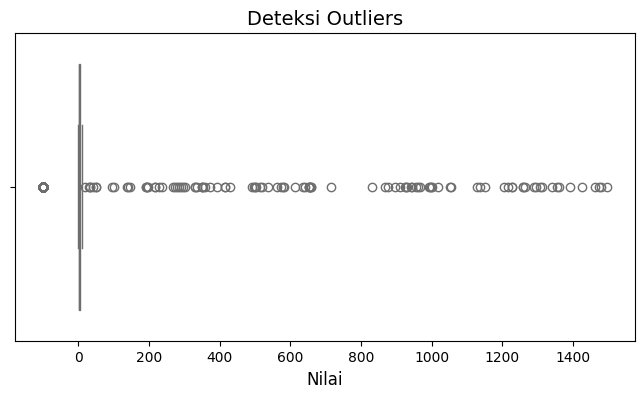

In [42]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['Num_of_Loan'], color='lightcoral')

plt.title('Deteksi Outliers', fontsize=14)
plt.xlabel('Nilai', fontsize=12)

plt.show()

setelah di cek num of loan, terlihat bahwa banyak sekali outlier sampai melebihi batas nilai IQR, sehingga saya cek lebih lanjut dengan membatasi valuenya

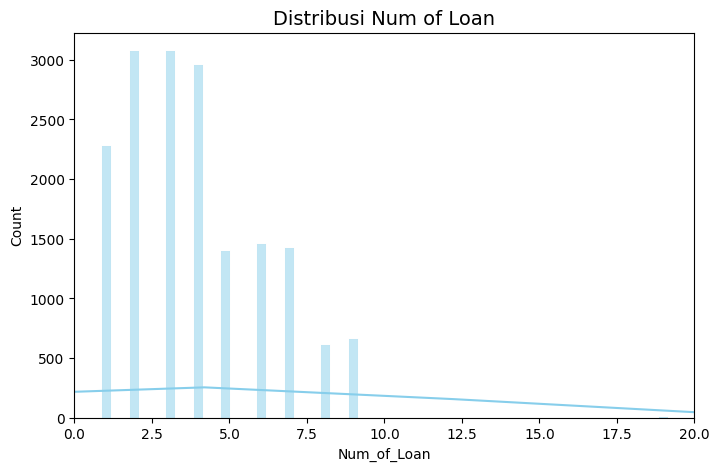

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Num_of_Loan'], kde=True, color='skyblue')

plt.xlim(0, 20) 

plt.title('Distribusi Num of Loan', fontsize=14)
plt.show()

In [44]:
col = 'Num_of_Loan'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 30

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 11.00
Jumlah data wajar: 20009 (99.49%)
Jumlah data anomali: 103 (0.51%)

Batas atas nominal sangat besar: 30.00
Jumlah data wajar: 20010 (99.49%)
Jumlah data anomali: 102 (0.51%)


In [45]:
print(df[df['Num_of_Loan'] > upper_bound]['Num_of_Loan'].mean())

684.0970873786408


In [46]:
df.loc[df['Num_of_Loan'] > upper_bound, 'Num_of_Loan'] = np.nan

Melalui perhitungan IQR, ditemukan upper bound 17 loan, di mana sekitar 0.51% data terdeteksi sebagai anomali dengan nilai mean tidak realistis mencapai 685 loan. Disimpulkan bahwa data tersebut merupakan eror sistem acak yang tidak masuk akal orang bisa meminjam sebanyak itu. Oleh karena itu, solusi terbaik adalah dengan mengubah nilai anomali di atas batas wajar tersebut menjadi nan, lalu mengimputasinya menggunakan nilai median.

#### 3.7.6. Number of Delayed Payment

In [47]:
col = 'Num_of_Delayed_Payment'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 400

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 31.50
Jumlah data wajar: 18904 (99.24%)
Jumlah data anomali: 144 (0.76%)

Batas atas nominal sangat besar: 400.00
Jumlah data wajar: 18918 (99.32%)
Jumlah data anomali: 130 (0.68%)


In [48]:
print(df[df[col] > upper_bound][col].mean())

2277.5763888888887


In [49]:
df.loc[df[col] > upper_bound, col] = np.nan

#### 3.7.7. Delay From Due date

In [50]:
col = 'Delay_from_due_date'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 500

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 52.50
Jumlah data wajar: 19986 (94.54%)
Jumlah data anomali: 1154 (5.46%)

Batas atas nominal sangat besar: 500.00
Jumlah data wajar: 21140 (100.00%)
Jumlah data anomali: 0 (0.00%)


tidak ditemukan adanya outlier

#### 3.7.8. Number of credit card

In [51]:
col = 'Num_Credit_Card'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 40

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 11.50
Jumlah data wajar: 20663 (97.74%)
Jumlah data anomali: 477 (2.26%)

Batas atas nominal sangat besar: 40.00
Jumlah data wajar: 20672 (97.79%)
Jumlah data anomali: 468 (2.21%)


In [52]:
df.loc[df[col] > upper_bound, col] = np.nan

tidak mungkin ada orang yang bisa punya 40 kartu kredit sehingga saya anggap itu data error dan dijadikan nan aja dan diimpute dengan median sehingga ga buang baris yang penting

#### 3.7.9. Monthly inhand salary

In [53]:
col = 'Monthly_Inhand_Salary'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 30000

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 19321.67
Jumlah data wajar: 17896 (100.00%)
Jumlah data anomali: 0 (0.00%)

Batas atas nominal sangat besar: 30000.00
Jumlah data wajar: 17896 (100.00%)
Jumlah data anomali: 0 (0.00%)


tidak ada data anomalinya

#### 3.7.10. Number of Bank Account

In [54]:
col = 'Num_Bank_Accounts'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 30

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 13.00
Jumlah data wajar: 20837 (98.57%)
Jumlah data anomali: 303 (1.43%)

Batas atas nominal sangat besar: 30.00
Jumlah data wajar: 20840 (98.58%)
Jumlah data anomali: 300 (1.42%)


In [55]:
df.loc[df[col] > upper_bound, col] = np.nan

#### 3.7.11. Changed Credit Limit

In [56]:
col = 'Changed_Credit_Limit'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 60

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 28.61
Jumlah data wajar: 20486 (98.89%)
Jumlah data anomali: 229 (1.11%)

Batas atas nominal sangat besar: 60.00
Jumlah data wajar: 20715 (100.00%)
Jumlah data anomali: 0 (0.00%)


tidak ditemukan adanya anomali

#### 3.7.12. Number of Credit Inquiries

In [57]:
col = 'Num_Credit_Inquiries'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)
nominal_gaje = 60

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 15.50
Jumlah data wajar: 20230 (97.54%)
Jumlah data anomali: 510 (2.46%)

Batas atas nominal sangat besar: 60.00
Jumlah data wajar: 20394 (98.33%)
Jumlah data anomali: 346 (1.67%)


In [58]:
df.loc[df[col] > upper_bound, col] = np.nan

#### 3.7.13. Outstanding Debt

In [59]:
col = 'Outstanding_Debt'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 10000

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 5753.95
Jumlah data wajar: 20903 (100.00%)
Jumlah data anomali: 0 (0.00%)

Batas atas nominal sangat besar: 10000.00
Jumlah data wajar: 20903 (100.00%)
Jumlah data anomali: 0 (0.00%)


tidak ada anomali

#### 3.7.14. Credit History Age

In [60]:
col = 'Credit_History_Age'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 1200

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 767.00
Jumlah data wajar: 19255 (100.00%)
Jumlah data anomali: 0 (0.00%)

Batas atas nominal sangat besar: 1200.00
Jumlah data wajar: 19255 (100.00%)
Jumlah data anomali: 0 (0.00%)


tidak ada anomali

#### 3.7.15. Total EMI per month

In [61]:
col = 'Total_EMI_per_month'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 1000

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 545.65
Jumlah data wajar: 20211 (95.61%)
Jumlah data anomali: 929 (4.39%)

Batas atas nominal sangat besar: 1000.00
Jumlah data wajar: 20403 (96.51%)
Jumlah data anomali: 737 (3.49%)


In [62]:
df.loc[df[col] > upper_bound, col] = np.nan

#### 3.7.16. Amount invested monthly

In [63]:
col = 'Amount_invested_monthly'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 1000

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 737.37
Jumlah data wajar: 18700 (96.86%)
Jumlah data anomali: 607 (3.14%)

Batas atas nominal sangat besar: 1000.00
Jumlah data wajar: 19107 (98.96%)
Jumlah data anomali: 200 (1.04%)


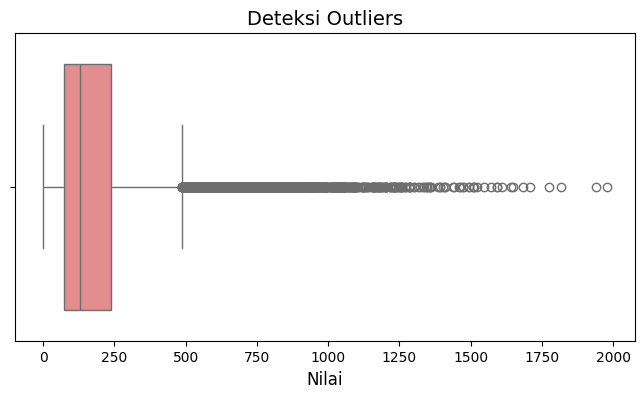

In [64]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df[col], color='lightcoral')

plt.title('Deteksi Outliers', fontsize=14)
plt.xlabel('Nilai', fontsize=12)

plt.show()

In [65]:
col = 'Amount_invested_monthly'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 1000

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 737.37
Jumlah data wajar: 18700 (96.86%)
Jumlah data anomali: 607 (3.14%)

Batas atas nominal sangat besar: 1000.00
Jumlah data wajar: 19107 (98.96%)
Jumlah data anomali: 200 (1.04%)


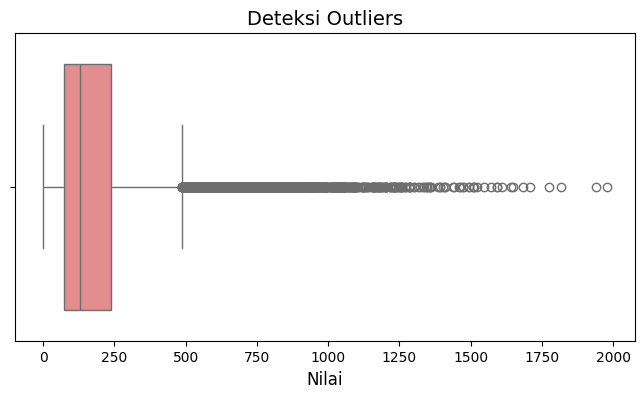

In [66]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df[col], color='lightcoral')

plt.title('Deteksi Outliers', fontsize=14)
plt.xlabel('Nilai', fontsize=12)

plt.show()

#### 3.7.17. Monthly Balance

In [67]:
col = 'Monthly_Balance'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (3 * IQR)
nominal_gaje = 1500

df_not_null = df[df[col].notna()]
total_data_valid = len(df_not_null)

kategori_wajar = df_not_null[col] <= upper_bound
jumlah_wajar = kategori_wajar.sum()
jumlah_anomali = (~kategori_wajar).sum()

kategori_wajar_1 = df_not_null[col] <= nominal_gaje
jumlah_wajar_1 = kategori_wajar_1.sum()
jumlah_anomali_1 = (~kategori_wajar_1).sum()

print(f"Batas atas nominal wajar: {upper_bound:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar} ({ (jumlah_wajar/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali} ({ (jumlah_anomali/total_data_valid)*100 :.2f}%)")

print(f"\nBatas atas nominal sangat besar: {nominal_gaje:.2f}")
print(f"Jumlah data wajar: {jumlah_wajar_1} ({ (jumlah_wajar_1/total_data_valid)*100 :.2f}%)")
print(f"Jumlah data anomali: {jumlah_anomali_1} ({ (jumlah_anomali_1/total_data_valid)*100 :.2f}%)")

Batas atas nominal wajar: 1111.10
Jumlah data wajar: 20593 (98.60%)
Jumlah data anomali: 293 (1.40%)

Batas atas nominal sangat besar: 1500.00
Jumlah data wajar: 20885 (100.00%)
Jumlah data anomali: 1 (0.00%)


tidak ada anomali

### 3.8. Imbalance Checking

In [68]:
print('Target Distribution')
target_counts = df['Credit_Score'].value_counts()
print(target_counts)
print(f'\nPercentage:\n{target_counts / len(df) * 100}')

Target Distribution
Credit_Score
1    11265
0     5941
2     3934
Name: count, dtype: int64

Percentage:
Credit_Score
1   53.28761
0   28.10312
2   18.60927
Name: count, dtype: float64


In [69]:
import pandas as pd

samples = df.groupby("Credit_Score").first().reset_index()

for idx, row in samples.iterrows():
    print(f"Kelas: {row['Credit_Score']}")
    print(row.to_dict())
    print("-" * 50)


Kelas: 0
{'Credit_Score': 0, 'Month': 'August', 'Age': 46.0, 'Occupation': 'Teacher', 'Annual_Income': 9786.86, 'Monthly_Inhand_Salary': 951.5716666666668, 'Num_Bank_Accounts': 9.0, 'Num_Credit_Card': 10.0, 'Interest_Rate': 11.0, 'Num_of_Loan': 2.0, 'Delay_from_due_date': 58, 'Num_of_Delayed_Payment': 14.0, 'Changed_Credit_Limit': 15.53, 'Num_Credit_Inquiries': 6.0, 'Credit_Mix': 'Standard', 'Outstanding_Debt': 2149.9, 'Credit_Utilization_Ratio': 23.451285243899484, 'Credit_History_Age': 190.0, 'Payment_of_Min_Amount': 'Yes', 'Total_EMI_per_month': 11.564437453875689, 'Amount_invested_monthly': 54.46174813453877, 'Monthly_Balance': 309.13098107825226, 'Spent_Level': 'Low', 'Payment_Value': 'Medium', 'personal_loan_freq': 1, 'student_loan_freq': 1, 'mortgage_loan_freq': 0, 'auto_loan_freq': 0, 'payday_loan_freq': 0, 'credit-builder_loan_freq': 0, 'home_equity_loan_freq': 0, 'debt_consolidation_loan_freq': 0.0}
--------------------------------------------------
Kelas: 1
{'Credit_Score': 

## 4. Preprocessing

In [70]:
target = 'Credit_Score'
x = df.drop(columns=[target])
y = df[target]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

num_col = x.select_dtypes(include='number').columns.tolist()
cat_col = x.select_dtypes(exclude='number').columns.tolist()

print(f'\nNumeric features ({len(num_col)}): {num_col}')
print(f'Categorical features ({len(cat_col)}): {cat_col}')


Numeric features (25): ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'personal_loan_freq', 'student_loan_freq', 'mortgage_loan_freq', 'auto_loan_freq', 'payday_loan_freq', 'credit-builder_loan_freq', 'home_equity_loan_freq', 'debt_consolidation_loan_freq']
Categorical features (6): ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Spent_Level', 'Payment_Value']


In [71]:
for i in cat_col:
    print(df[i].value_counts())
    print("\n"*1)

Month
February    2734
March       2657
June        2641
January     2640
May         2629
July        2621
August      2616
April       2602
Name: count, dtype: int64


Occupation
Unknown          1490
Lawyer           1410
Teacher          1377
Mechanic         1373
Journalist       1343
Architect        1330
Developer        1327
Accountant       1316
Media_Manager    1306
Scientist        1300
Engineer         1291
Doctor           1281
Musician         1272
Entrepreneur     1259
Manager          1259
Writer           1206
Name: count, dtype: int64


Credit_Mix
Standard    7695
Good        5464
Bad         3812
Name: count, dtype: int64


Payment_of_Min_Amount
Yes    10637
No      8016
NM      2487
Name: count, dtype: int64


Spent_Level
Low     11403
High     9737
Name: count, dtype: int64


Payment_Value
Small     8320
Medium    7243
Large     5577
Name: count, dtype: int64




In [72]:
spent_level_order = ['Low', 'High']
payment_value_order = ['Small', 'Medium', 'Large']
credit_mix_order = ['Bad', 'Standard', 'Good']
payment_min_order = ['NM', 'Yes', 'No']

numeric_imputer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

ordinal_spent_level = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Ordinal_Spent', OrdinalEncoder(categories=[spent_level_order]))
])

ordinal_payment_value = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Ordinal_Value', OrdinalEncoder(categories=[payment_value_order]))
])

ordinal_Credit_Mix = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Ordinal_Credit', OrdinalEncoder(categories=[credit_mix_order]))
])

ordinal_Payment_Min_Amount = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Ordinal_Min_Amount', OrdinalEncoder(categories=[payment_min_order]))
])

OHE_nominal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('OHE', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [73]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_imputer', numeric_imputer, num_col),
        ('ordinal_SL', ordinal_spent_level, ['Spent_Level']),
        ('ordinal_PV', ordinal_payment_value, ['Payment_Value']),
        ('ordinal_CM', ordinal_Credit_Mix, ['Credit_Mix']),
        ('ordinal_PMA', ordinal_Payment_Min_Amount, ['Payment_of_Min_Amount']),
        ('ohe', OHE_nominal, ['Month', 'Occupation'])
    ], remainder='passthrough'
)

## 5. Baseline Modelling (6 Models)

Membandingkan 6 algoritma:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM (Support Vector Machine)
5. Gradient Boosting
6. XGBoost

In [74]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
}

report_records = []
fitted_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(x_train, y_train)
    
    fitted_pipelines[name] = pipeline
    
    y_pred = pipeline.predict(x_test)
    
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    report_records.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Macro Avg F1': report['macro avg']['f1-score'],
        'Bad_Class F1': report['0']['f1-score'],
        'Bad_Class Recall': report['0']['recall']
    })

df_compare = pd.DataFrame(report_records).sort_values(by='Macro Avg F1', ascending=False).reset_index(drop=True)
print("Hasil Perbandingan Model")
print(df_compare)

top_1_model_name = df_compare.loc[0, 'Model']
top_2_model_name = df_compare.loc[1, 'Model']

print(f"\nTop 2 Model Terbaik: 1. {top_1_model_name} | 2. {top_2_model_name}")

Hasil Perbandingan Model
                 Model  Accuracy  Macro Avg F1  Bad_Class F1  Bad_Class Recall
0        Random Forest   0.72162       0.70306       0.71221           0.70202
1              XGBoost   0.71973       0.69782       0.69625           0.68013
2    Gradient Boosting   0.69939       0.67870       0.66338           0.62290
3        Decision Tree   0.62417       0.59710       0.59145           0.61111
4  Logistic Regression   0.60383       0.51823       0.52522           0.44697
5                  SVM   0.53619       0.29129       0.18845           0.11532

Top 2 Model Terbaik: 1. Random Forest | 2. XGBoost


Alasan utama berfokus mencari kelas 0 adalah karena dalam bisnis perbankan dan risiko kredit, biaya kerugian akibat salah mendeteksi nasabah macet jauh lebih besar daripada kehilangan nasabah jujur.

## 6. Top 2 Models Hyperparameter Tuning

### 6.1. Random Forest 

In [75]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-2))
])

param_grid_rf = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 8],
}

rs_rf = RandomizedSearchCV(
    estimator=pipeline_rf, 
    param_distributions=param_grid_rf, 
    n_iter=30, 
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', 
    verbose=1,                 
    random_state=42, 
    n_jobs=-3
)

rs_rf.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 15, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategi

### 6.2. Random Forest With Class Weight Balanced

In [76]:
pipeline_cw = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-2
    ))
])

param_grid_rf = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}

search_cw = RandomizedSearchCV(
    estimator=pipeline_cw,
    param_distributions=param_grid_rf,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    random_state=42,
    n_jobs=-3,
    verbose=1
)

search_cw.fit(x_train, y_train)

print("Best Hyperparameters:", search_cw.best_params_)
print(f"Best CV Macro F1 Score: {search_cw.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}
Best CV Macro F1 Score: 0.7057


### 6.3. XGB Baseline

In [77]:
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', XGBClassifier(
        num_class = 3,
        random_state=42, 
        n_jobs=-1,
        eval_metric='mlogloss',
        verbosity=0
    ))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8],           
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],        
    'model__colsample_bytree': [0.7, 0.8, 0.9],
}

rs_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb, 
    param_distributions=param_grid_xgb, 
    n_iter=30, 
    cv=StratifiedKFold(5, shuffle=True, random_state=42),                      
    scoring='f1_weighted', 
    verbose=1,                 
    random_state=42, 
    n_jobs=-3
)

rs_xgb.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ass=3, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 6, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-vali

### 6.4. XGB With Class Weight Balanced

In [80]:
pipeline_xgb_weighted = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        num_class=3,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        verbosity=0
    ))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8],           
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],        
    'model__colsample_bytree': [0.7, 0.8, 0.9],
}

sample_weights = compute_sample_weight('balanced', y_train)

rs_xgb_weighted = RandomizedSearchCV(
    estimator=pipeline_xgb_weighted, 
    param_distributions=param_grid_xgb,
    n_iter=30,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro',
    random_state=42,
    n_jobs=-3,
    verbose=1
)


rs_xgb_weighted.fit(x_train, y_train, model__sample_weight=sample_weights)

print("Best Hyperparameters:", rs_xgb_weighted.best_params_)
print(f"Best CV Macro F1 Score: {rs_xgb_weighted.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters: {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best CV Macro F1 Score: 0.7050


### 6.5. Evaluasi

In [79]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

models_to_evaluate = {
    "RF Baseline": rs_rf.best_estimator_,
    "RF Class Weight": search_cw.best_estimator_,
    "XGB Baseline": rs_xgb.best_estimator_, 
    "XGB Class Weight": rs_xgb_weighted.best_estimator_ 
}

data_report = []

for name, model in models_to_evaluate.items():
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    
    data_report.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1': report['macro avg']['f1-score'],
        'ROC AUC': roc_auc,
        'Recall C-0 (Bad)': report.get('0', {}).get('recall'),
        'Recall C-1 (Standard)': report.get('1', {}).get('recall'),
        'Recall C-2 (Good)': report.get('2', {}).get('recall')
    })

df_eval = pd.DataFrame(data_report)
print(df_eval.to_string(index=False))

           Model  Accuracy  Macro Precision  Macro Recall  Macro F1  ROC AUC  Recall C-0 (Bad)  Recall C-1 (Standard)  Recall C-2 (Good)
     RF Baseline   0.72446          0.70496       0.70770   0.70597  0.87032           0.69360                0.75988            0.66963
 RF Class Weight   0.72564          0.70271       0.73404   0.71409  0.86952           0.72138                0.71327            0.76747
    XGB Baseline   0.73132          0.71705       0.70758   0.71206  0.87419           0.69360                0.77985            0.64930
XGB Class Weight   0.72966          0.70658       0.73454   0.71760  0.87533           0.73485                0.72037            0.74841
